# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset.

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
# Inspect the shapes of the datasets
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


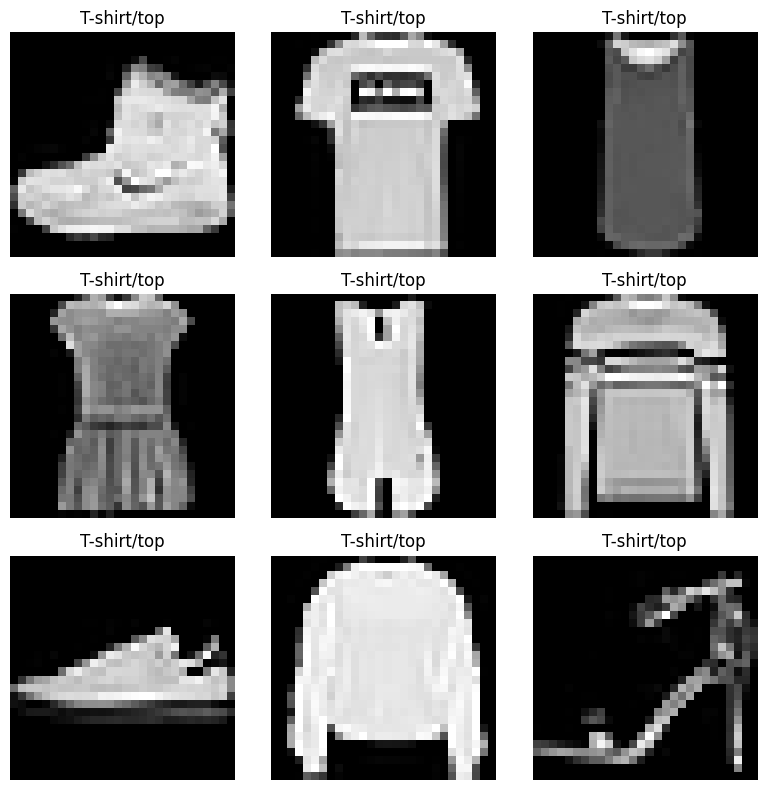

In [3]:
import matplotlib.pyplot as plt
# Verify the data looks as expected
plt.figure(figsize=(8, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i].argmax()])
    plt.axis('off')
plt.tight_layout()
plt.show()

Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

The dataset looks normal. Each image is a 28x28 grid of grayscale pixels. Image shows clothing items.
The pixel resolution is adequate to separate categories such as Sneaker, Pullover or sandals.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [4]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical
y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

# Create a simple linear regression model
model = Sequential()
model.add(Flatten(input_shape=(28, 28)))  # Flatten dataset
model.add(Dense(10, activation='softmax'))  # softmax classification, 10 classes

# You can use `model.add(<layer>)` to add layers to the model
# Compile the model using `model.compile()`
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])
# Train the model with `model.fit()`
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate the model with `model.evaluate()`
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print(f"Test Loss: {test_loss:.4f}")
print(f"Test Accuracy: {test_accuracy:.4f}")

/usr/local/lib/python3.11/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.7218 - loss: 0.8246 - val_accuracy: 0.8306 - val_loss: 0.4929
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8357 - loss: 0.4821 - val_accuracy: 0.8382 - val_loss: 0.4648
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8463 - loss: 0.4483 - val_accuracy: 0.8447 - val_loss: 0.4491
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8519 - loss: 0.4319 - val_accuracy: 0.8526 - val_loss: 0.4370
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8600 - loss: 0.4116 - val_accuracy: 0.8519 - val_loss: 0.4264
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8575 - loss: 0.4096 - val_accuracy: 0.8533 - val_loss: 0.4231
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 3ms/step - accuracy: 0.8609 - loss: 0.4020 - val_accuracy: 0.8573 - val_loss: 0.4201
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 4ms/step - accuracy: 0.8618 - loss: 0.3963 - 

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

The baseline model accuracy was 0.85 (range from 0.72 to 0.86). The accuracy is higher given this is a baseline model based on a simple linear regression. It can be expected that further complex model will improve the accuracy.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [6]:
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from keras.models import Sequential

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
model.add(Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))

# compile
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history = model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.8047 - loss: 0.5752 - val_accuracy: 0.8708 - val_loss: 0.3563
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 48s 26ms/step - accuracy: 0.8955 - loss: 0.2910 - val_accuracy: 0.9013 - val_loss: 0.2759
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 39s 25ms/step - accuracy: 0.9091 - loss: 0.2432 - val_accuracy: 0.9073 - val_loss: 0.2605
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 36s 21ms/step - accuracy: 0.9254 - loss: 0.2078 - val_accuracy: 0.9071 - val_loss: 0.2610
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9300 - loss: 0.1866 - val_accuracy: 0.9070 - val_loss: 0.2557
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 41s 22ms/step - accuracy: 0.9412 - loss: 0.1604 - val_accuracy: 0.9123 - val_loss: 0.2549
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 44s 24ms/step - accuracy: 0.9498 - loss: 0.1389 - val_accuracy: 0.9082 - val_loss: 0.2738
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 38s 22ms/step - accuracy: 0.9555 -

Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

The CNN model significantly performed better than the baseline model. The CNN model accuracy ranged from 0.80 to 0.969 compared to 0.72 to 0.86 in the baseline model. I think the improvement in the performance is due to the collective effects of the Conv2D filters and MaxPooling.

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

In [7]:
# A. Test Hyperparameters
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
import numpy as np

## object to store result
results_filters = {}

# Loop
for filters in [32, 64, 128]:
    print(f"\nTraining model with {filters} filters:")

    model = Sequential()
    model.add(Conv2D(filters, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())
    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    print(f"Test accuracy: {test_accuracy:.4f}")
    results_filters[filters] = test_accuracy


Training model with 32 filters:
Test accuracy: 0.9061

Training model with 64 filters:
Test accuracy: 0.9108

Training model with 128 filters:
Test accuracy: 0.9043


In [8]:
# B. Test regularization

from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# result object
results_dropout = {}

for use_dropout in [False, True]:
    print(f"\nTraining model with dropout = {use_dropout}")

    model = Sequential()
    model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)))
    model.add(MaxPooling2D(pool_size=(2, 2)))
    model.add(Flatten())

    if use_dropout:
        model.add(Dropout(0.3))  # Drop neurons

    model.add(Dense(64, activation='relu'))
    model.add(Dense(10, activation='softmax'))

    model.compile(optimizer='adam',
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])

    model.fit(X_train, y_train, epochs=5, batch_size=32, verbose=0)
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    print(f"Test accuracy: {test_accuracy:.4f}")
    results_dropout[use_dropout] = test_accuracy


Training model with dropout = False
Test accuracy: 0.9032

Training model with dropout = True
Test accuracy: 0.9070


Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

The model achieved accuracy of 0.91 with 64 filters. Increasing the filter size to 128 did not improve the model accuracy (0.90). Adding a dropout layer resulted in a very small improvement in the model performance (0.907)compared to a model without dropout layer (0.903). In summary, a model with 64 filters and 30% dropout was the best performing model/

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [10]:
from keras.models import Sequential
from keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

# Build final model (with dropout)
final_model = Sequential()
final_model.add(Conv2D(64, (3, 3), activation='relu', input_shape=(28, 28, 1)))
final_model.add(MaxPooling2D(pool_size=(2, 2)))
final_model.add(Flatten())
final_model.add(Dropout(0.3))  # Drop 30% of neurons
final_model.add(Dense(64, activation='relu'))
final_model.add(Dense(10, activation='softmax'))

final_model.compile(optimizer='adam',
                    loss='categorical_crossentropy',
                    metrics=['accuracy'])

final_model.fit(X_train, y_train, epochs=10, batch_size=32, validation_split=0.2)

# Evaluate on test set
final_loss, final_accuracy = final_model.evaluate(X_test, y_test)
print(f"Final Test Accuracy: {final_accuracy:.4f}")
print(f"Final Test Loss: {final_loss:.4f}")


Epoch 1/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 65s 43ms/step - accuracy: 0.8012 - loss: 0.5621 - val_accuracy: 0.8813 - val_loss: 0.3279
Epoch 2/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 63s 42ms/step - accuracy: 0.8909 - loss: 0.3000 - val_accuracy: 0.9003 - val_loss: 0.2783
Epoch 3/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 63s 42ms/step - accuracy: 0.9068 - loss: 0.2542 - val_accuracy: 0.9061 - val_loss: 0.2577
Epoch 4/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 60s 40ms/step - accuracy: 0.9175 - loss: 0.2239 - val_accuracy: 0.9072 - val_loss: 0.2561
Epoch 5/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 81s 40ms/step - accuracy: 0.9287 - loss: 0.1979 - val_accuracy: 0.9133 - val_loss: 0.2404
Epoch 6/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 85s 42ms/step - accuracy: 0.9338 - loss: 0.1759 - val_accuracy: 0.9049 - val_loss: 0.2699
Epoch 7/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 80s 41ms/step - accuracy: 0.9386 - loss: 0.1621 - val_accuracy: 0.9141 - val_loss: 0.2541
Epoch 8/10
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 86s 43ms/step - accuracy: 0.9476 -

Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

The final model with a combination of 64 filters and 30% dropout reached a accuracy of 0.91. Compared to baseline model, the final model had significant improvement in accuracy (0.85 Vs. 0.91). However, compared to CNN, the final model did not produce significant improvements. Hyperparameter tuning is an important factor in improvement of model performance. I would consider adding more conv2D layers, and additional regularization parameters to further improve the model performances.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 06/07/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-6-ml-help`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.